# Solar neutrinos, the MSW resonance, and the limits of slabs

The adiabatic MSW resonance in the Sun is the textbook application of matter effects. This notebook does it with slabs, gets the right answer, and then explains why you should probably not do it this way.

**The short version:** the method works and is validated here against the analytic adiabatic result, but the cost of a realistic solar calculation makes a Magnus-type method the better tool. The last section gives the numbers.

In [1]:
import sys
import os

# Works whether or not the package is installed: these notebooks sit one
# level below the repository root, so src/ is one directory up.
sys.path.insert(0, os.path.abspath(os.path.join('..', 'src')))

import numpy as np
import matplotlib.pyplot as plt

import globaldefs as gd
import oscprob2nu
import oscprob3nu
import oscprob4nu
import hamiltonians2nu
import hamiltonians3nu
import hamiltonians4nu

%matplotlib inline
plt.rcParams.update({'figure.figsize': (7.2, 4.2), 'figure.dpi': 90,
                     'axes.grid': True, 'grid.alpha': 0.3,
                     'font.size': 11, 'legend.frameon': False,
                     # Axes end exactly at the data: no padding beyond
                     # x_min/x_max or y_min/y_max.
                     'axes.xmargin': 0.0, 'axes.ymargin': 0.0})

# The three-flavor vacuum Hamiltonian at the NuFit best fit, normal ordering.
# It is energy-independent; dividing by the energy is what the builders do.
H_VAC_3NU = hamiltonians3nu.hamiltonian_3nu_vacuum_energy_independent(
    gd.S12_NO_BF, gd.S23_NO_BF, gd.S13_NO_BF, gd.DCP_NO_BF,
    gd.D21_NO_BF, gd.D31_NO_BF)

KM = gd.CONV_KM_TO_INV_EV      # multiply a length in km to get eV^-1
GEV = 1.0e9                    # multiply an energy in GeV to get eV

In [2]:
import slabs
import earth   # matter_potential is not Earth-specific

## A solar density profile

The density falls roughly exponentially through the radiative zone: $\rho(r) \simeq \rho_0 e^{-r/r_0}$ with $\rho_0 \approx 150$ g/cm$^3$ and $r_0 \approx R_\odot/10.54$.

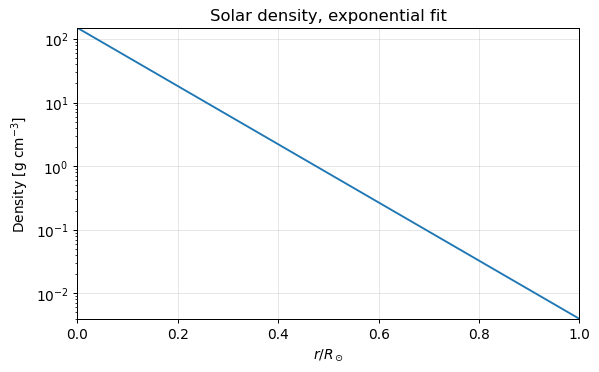

In [3]:
R_SUN_KM = 6.957e5
RHO_CENTRE = 150.0                 # [g cm^-3]
R_SCALE = R_SUN_KM/10.54


def density_sun(r_km):
    """Exponential fit to the solar density profile."""
    return RHO_CENTRE*np.exp(-np.asarray(r_km, dtype=float)/R_SCALE)


H2_VAC_SOLAR = hamiltonians2nu.hamiltonian_2nu_vacuum_energy_independent(
    gd.S12_NO_BF, gd.D21_NO_BF)

r = np.linspace(0.0, R_SUN_KM, 2000)
fig, ax = plt.subplots()
ax.semilogy(r/R_SUN_KM, density_sun(r))
ax.set_xlim(0.0, 1.0)
ax.set_xlabel(r"$r/R_\odot$")
ax.set_ylabel(r"Density [g cm$^{-3}$]")
ax.set_title("Solar density, exponential fit")
plt.show()

## Where the resonance sits

The MSW resonance is where the matter term matches the vacuum one, $2EV = \Delta m^2 \cos 2\theta$. A 10 MeV neutrino is produced *above* resonance and crosses it on the way out, which is the condition for MSW conversion.

V at the centre    : 5.679e-12 eV
resonant potential : 1.404e-12 eV
crossed at r       : 0.133 R_sun


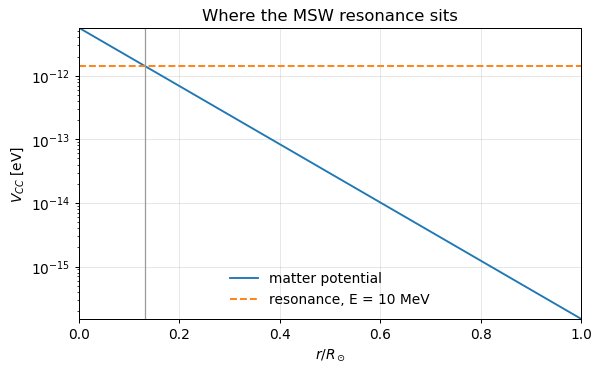

In [4]:
E_mev = 10.0
E = E_mev*1.0e6
cos2th = 1.0 - 2.0*gd.S12_NO_BF**2.0

v_res = gd.D21_NO_BF*cos2th/(2.0*E)
v_of_r = earth.matter_potential(density_sun(r))
k = int(np.argmin(np.abs(v_of_r - v_res)))

print("V at the centre    : %.3e eV" % v_of_r[0])
print("resonant potential : %.3e eV" % v_res)
print("crossed at r       : %.3f R_sun" % (r[k]/R_SUN_KM))

fig, ax = plt.subplots()
ax.semilogy(r/R_SUN_KM, v_of_r, label="matter potential")
ax.axhline(v_res, color="C1", ls="--",
           label="resonance, E = 10 MeV")
ax.axvline(r[k]/R_SUN_KM, color="0.6", lw=1)
ax.set_xlim(0.0, 1.0)
ax.set_xlabel(r"$r/R_\odot$")
ax.set_ylabel(r"$V_{CC}$ [eV]")
ax.set_title("Where the MSW resonance sits")
ax.legend()
plt.show()

## Slabbing the Sun

A slab is exact only if the Hamiltonian is constant across it, so the slabs must be short compared with the oscillation length. That sets the count.

In [5]:
def probabilities_sun(n_slabs, energy):
    """Two-flavor survival through the solar profile."""
    edges = np.linspace(0.0, R_SUN_KM, n_slabs+1)
    widths = np.diff(edges)
    mid = 0.5*(edges[:-1]+edges[1:])
    vcc = earth.matter_potential(density_sun(mid))
    H = hamiltonians2nu.hamiltonian_2nu_matter(
        H2_VAC_SOLAR, energy, vcc)
    return np.array(slabs.probabilities_2nu_slabs(H, widths*KM))


L_osc_km = 4.0*np.pi*E/gd.D21_NO_BF/KM
print("oscillation length at 10 MeV : %.1f km" % L_osc_km)
print("path to cross                : %.3e km" % R_SUN_KM)
print("slabs at ~10 per oscillation : %.1e"
      % (10.0*R_SUN_KM/L_osc_km))

for n in (100, 300, 1000, 3000, 10000, 30000):
    print("%7d slabs -> P_ee = %.6f" % (n, probabilities_sun(n, E)[0]))

oscillation length at 10 MeV : 335.5 km
path to cross                : 6.957e+05 km
slabs at ~10 per oscillation : 2.1e+04
    100 slabs -> P_ee = 0.721297
    300 slabs -> P_ee = 0.617056
   1000 slabs -> P_ee = 0.604603
   3000 slabs -> P_ee = 0.549955
  10000 slabs -> P_ee = 0.535065
  30000 slabs -> P_ee = 0.535072


It converges at around ten thousand slabs, against an estimate of twenty thousand — the right order, which is all a back-of-the-envelope count of oscillation lengths can be expected to give. So far so good.

And then the trap.

## The converged number is meaningless on its own

That $P_{ee}$ is the survival probability for one energy, at one production point, evaluated at one radius. Move the energy by a tenth of a percent and it changes completely.

In [6]:
for e in np.linspace(0.999e7, 1.001e7, 7):
    print("E = %.4f MeV -> P_ee = %.4f"
          % (e/1.0e6, probabilities_sun(8000, e)[0]))

E = 9.9900 MeV -> P_ee = 0.5649
E = 9.9933 MeV -> P_ee = 0.0725
E = 9.9967 MeV -> P_ee = 0.4395
E = 10.0000 MeV -> P_ee = 0.5351
E = 10.0033 MeV -> P_ee = 0.0647
E = 10.0067 MeV -> P_ee = 0.4816
E = 10.0100 MeV -> P_ee = 0.4952


The probability is oscillating far faster than any detector resolves, and faster than the production region is localised. The physical quantity is the **average**, and nothing about a single evaluation approximates it.

## Averaging recovers the textbook result

Averaged over a narrow energy band, the slab calculation should reproduce the analytic adiabatic MSW prediction

$$ \langle P_{ee} \rangle = \tfrac{1}{2}\left(1 + \cos 2\theta_m^0 \cos 2\theta\right), $$

with $\theta_m^0$ the mixing angle at the production point. This is the check that the whole machinery is right.

In [7]:
x = 2.0*E*v_of_r[0]/gd.D21_NO_BF
cos2th_m = (cos2th-x)/np.sqrt((cos2th-x)**2.0 + (1.0-cos2th**2.0))
p_adiabatic = 0.5*(1.0 + cos2th_m*cos2th)

energies = np.linspace(0.99e7, 1.01e7, 200)
p_avg = np.mean([probabilities_sun(4000, e)[0] for e in energies])

print("adiabatic MSW prediction : %.4f" % p_adiabatic)
print("slabs, averaged          : %.4f" % p_avg)
print("difference               : %.4f"
      % abs(p_avg-p_adiabatic))
print()
print("for contrast, no MSW at all (vacuum-averaged): %.4f"
      % (1.0 - 0.5*(1.0-cos2th**2.0)))

adiabatic MSW prediction : 0.3516
slabs, averaged          : 0.3527
difference               : 0.0011

for contrast, no MSW at all (vacuum-averaged): 0.5722


It agrees to a fraction of a percent, and is clearly distinct from the vacuum-averaged value — the conversion is real and the slab calculation captures it.

## Why you should still not do it this way

Count what that took. One averaged point needed **4000 slabs x 200 energies = 800 000 slab evaluations**, and that is the cheapest possible version of the problem: two flavors, one production radius, one narrow energy band, an analytic density profile.

A real solar calculation needs, on top of that:

* three flavors rather than two;
* an average over the production region, which spans a range of radii for each reaction and differs between the pp, $^7$Be and $^8$B components;
* a spectrum rather than a single energy;
* the day-night effect, which adds an Earth crossing on top.

Each of those is a multiplier. The cost grows as the path length divided by the oscillation length — and the oscillation length shrinks with energy, so the problem gets worse exactly where the interesting physics is.

None of this is a defect in the method. Every slab is still exact. The difficulty is that a piecewise-constant approximation is the wrong shape for a profile that varies smoothly over many oscillation lengths: it needs its step size set by the *oscillation*, not by the *variation of the Hamiltonian*, and those differ here by four orders of magnitude.

### Use a Magnus expansion instead

A Magnus-type method integrates the varying Hamiltonian directly rather than freezing it in pieces, so its step size is set by how fast the Hamiltonian changes, and it converges at high order in that step. For a smooth profile crossed over many oscillations this is the difference between $10^4$ steps and a few dozen.

The sibling package [Magnus](https://github.com/mbustama/Magnus) does exactly this, and shares this library's conventions and its set of named locations.

**Rule of thumb.** Use NuOscProbExact where the Hamiltonian is constant or genuinely piecewise-constant: a beam through the crust, a trajectory through the Earth, a castle wall. Use a Magnus-type method where it varies smoothly on the scale of an oscillation length, as it does in the Sun.

---

**Previous:** [Antineutrinos, done properly](13_antineutrinos.ipynb)  
**Next:** [Numerical edge cases](15_numerical_edge_cases.ipynb) --- degeneracies, and what returns a number instead of NaN  
[API reference](https://mbustama.github.io/NuOscProbExact/functions.html) &middot; [Numerical recipes](https://mbustama.github.io/NuOscProbExact/recipes.html) &middot; [All notebooks](.)